In [2]:
import re, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)

warnings.filterwarnings("ignore")

SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")


Device : cpu


## 2. Load Dataset

In [3]:
df = pd.read_csv("Amazon_Reviews.csv")
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)


Shape  : (21214, 9)
Columns: ['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"


## 3. Exploratory Data Analysis

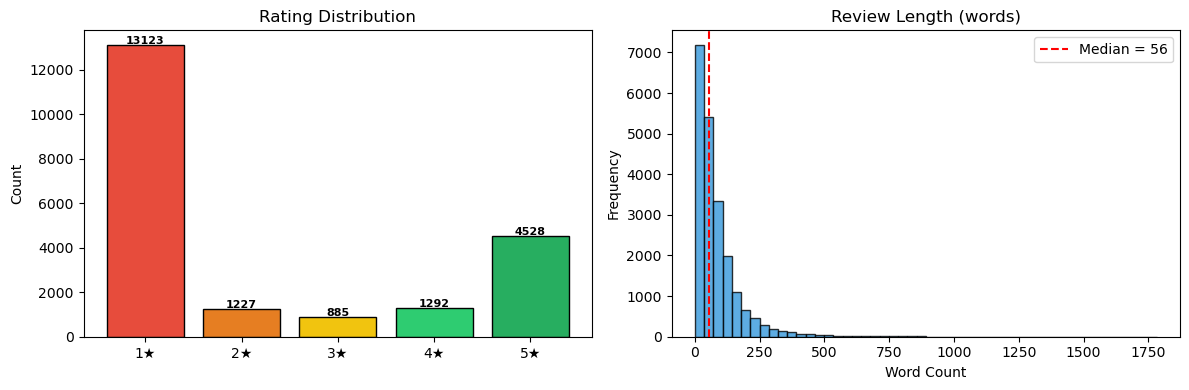

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rating distribution
counts = df["Rating"].value_counts().sort_index()
short_labels = ["1★","2★","3★","4★","5★"]
axes[0].bar(short_labels, counts.values,
            color=["#e74c3c","#e67e22","#f1c40f","#2ecc71","#27ae60"],
            edgecolor="black")
axes[0].set_title("Rating Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=8, fontweight="bold")

# Review text length
df["word_count"] = df["Review Text"].fillna("").str.split().str.len()
axes[1].hist(df["word_count"], bins=50, color="#3498db", edgecolor="black", alpha=0.8)
axes[1].set_title("Review Length (words)")
axes[1].set_xlabel("Word Count"); axes[1].set_ylabel("Frequency")
axes[1].axvline(df["word_count"].median(), color="red", linestyle="--",
                label=f'Median = {df["word_count"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Data Preprocessing
- Drop rows where `Review Text` is null  
- Convert star ratings → binary labels: **1–2 = Negative (0)**, **4–5 = Positive (1)**, drop 3★ (neutral)  
- Clean text: strip HTML, normalize whitespace  
- **Undersample** majority class (1★ is heavily over-represented) for balanced training


In [5]:
def clean_text(text: str) -> str:
    text = re.sub(r"<[^>]+>", " ", str(text))
    text = re.sub(r"[^a-zA-Z0-9\s.,!?'\"\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Drop nulls
df.dropna(subset=["Review Text"], inplace=True)

# Extract numeric rating
df["stars"] = df["Rating"].str.extract(r"(\d)").astype(int)

# Keep only 1-2 (negative) and 4-5 (positive), drop neutral 3★
df = df[df["stars"] != 3].copy()
df["label"] = (df["stars"] >= 4).astype(int)   # 1 = Positive, 0 = Negative

# Clean text
df["clean_text"] = df["Review Text"].apply(clean_text)

print("Class distribution before balancing:")
print(df["label"].value_counts())

# Balance: sample equal numbers from each class
n_pos = df[df["label"] == 1].shape[0]
n_neg = df[df["label"] == 0].shape[0]
n_sample = min(n_pos, n_neg, 3000)          # cap at 3000 each → 6000 total (fast!)

df_pos = df[df["label"] == 1].sample(n_sample, random_state=SEED)
df_neg = df[df["label"] == 0].sample(n_sample, random_state=SEED)
df_bal = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nAfter balancing: {df_bal.shape[0]} rows")
print(df_bal["label"].value_counts())


Class distribution before balancing:
label
0    14350
1     5820
Name: count, dtype: int64

After balancing: 6000 rows
label
1    3000
0    3000
Name: count, dtype: int64


## 5. Train / Validation / Test Split (70 / 15 / 15)

In [6]:
df_train, df_temp = train_test_split(df_bal, test_size=0.30, random_state=SEED,
                                     stratify=df_bal["label"])
df_val, df_test  = train_test_split(df_temp, test_size=0.50, random_state=SEED,
                                     stratify=df_temp["label"])

print(f"Train : {len(df_train):>5}")
print(f"Val   : {len(df_val):>5}")
print(f"Test  : {len(df_test):>5}")


Train :  4200
Val   :   900
Test  :   900


## 6. Tokenization
Using `distilbert-base-uncased` — 40 % smaller and 60 % faster than BERT,  
while retaining ~97 % of performance. `max_length = 128` keeps memory low.


In [7]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN    = 128                         # Amazon reviews are short — 128 is enough

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Quick sanity check
sample_enc = tokenizer(df_train["clean_text"].iloc[0],
                       max_length=MAX_LEN, truncation=True,
                       padding="max_length", return_tensors="pt")
print("Input IDs  shape:", sample_enc["input_ids"].shape)
print("Sample tokens   :", tokenizer.convert_ids_to_tokens(
      sample_enc["input_ids"][0][:12].tolist()))


Input IDs  shape: torch.Size([1, 128])
Sample tokens   : ['[CLS]', 'great', 'place', 'to', 'shop', ',', 'their', 'customer', 'service', 'is', 'a', 'bit']


## 7. PyTorch Dataset & DataLoaders

In [8]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            truncation=True, padding="max_length", return_tensors="pt"
        )
        return {
            "input_ids"      : enc["input_ids"].squeeze(0),
            "attention_mask" : enc["attention_mask"].squeeze(0),
            "label"          : torch.tensor(self.labels[idx], dtype=torch.long),
        }

BATCH_SIZE = 32          # larger batch = fewer steps = faster

train_ds = ReviewDataset(df_train["clean_text"], df_train["label"], tokenizer, MAX_LEN)
val_ds   = ReviewDataset(df_val["clean_text"],   df_val["label"],   tokenizer, MAX_LEN)
test_ds  = ReviewDataset(df_test["clean_text"],  df_test["label"],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")


Train batches : 132
Val   batches : 29
Test  batches : 29


## 8. Training Utilities

In [9]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="  Training", leave=False):
        ids    = batch["input_ids"].to(device)
        mask   = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        out = model(input_ids=ids, attention_mask=mask, labels=labels)
        out.loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += out.loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0
    with torch.no_grad():
        for batch in loader:
            ids    = batch["input_ids"].to(device)
            mask   = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            out    = model(input_ids=ids, attention_mask=mask, labels=labels)
            total_loss += out.loss.item()
            preds = torch.argmax(out.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    metrics = {
        "loss"     : total_loss / len(loader),
        "accuracy" : accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, average="binary"),
        "recall"   : recall_score(all_labels, all_preds, average="binary"),
        "f1"       : f1_score(all_labels, all_preds, average="binary"),
    }
    return metrics, all_preds, all_labels


def plot_cm(labels, preds, title, filename):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative","Positive"],
                yticklabels=["Negative","Positive"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_curves(history, title, filename):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], "bo-", label="Train Loss")
    axes[0].plot(epochs, history["val_loss"],   "ro-", label="Val Loss")
    axes[0].set_title(f"{title} — Loss"); axes[0].legend()
    axes[1].plot(epochs, history["val_acc"], "go-", label="Val Accuracy")
    axes[1].plot(epochs, history["val_f1"],  "mo-", label="Val F1")
    axes[1].set_title(f"{title} — Metrics"); axes[1].set_ylim(0,1); axes[1].legend()
    plt.tight_layout()
    plt.show()


## 9. Experiment Runner

In [10]:
def run_experiment(exp_name, freeze_mode, epochs=3, lr=2e-5):
    """
    freeze_mode:
      'all'   → freeze all DistilBERT layers, train classifier head only
      'last1' → freeze all except last transformer block + classifier
      'none'  → full fine-tuning
    """
    print(f"\n{'='*55}")
    print(f"  {exp_name}  |  freeze={freeze_mode}  |  epochs={epochs}")
    print(f"{'='*55}")

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    ).to(DEVICE)

    if freeze_mode == "all":
        for param in model.distilbert.parameters():
            param.requires_grad = False

    elif freeze_mode == "last1":
        for param in model.distilbert.parameters():
            param.requires_grad = False
        # Un-freeze last transformer block only
        for param in model.distilbert.transformer.layer[-1].parameters():
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

    optimizer   = AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    history = {"train_loss":[], "val_loss":[], "val_acc":[], "val_f1":[]}
    best_f1, best_state = 0, None

    for epoch in range(1, epochs + 1):
        t_loss = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        v_met, _, _ = evaluate(model, val_loader, DEVICE)
        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_met["loss"])
        history["val_acc"].append(v_met["accuracy"])
        history["val_f1"].append(v_met["f1"])
        print(f"  Epoch {epoch}/{epochs}  "
              f"Train Loss: {t_loss:.4f}  "
              f"Val Acc: {v_met['accuracy']:.4f}  "
              f"Val F1: {v_met['f1']:.4f}")
        if v_met["f1"] > best_f1:
            best_f1    = v_met["f1"]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    # Load best checkpoint for test eval
    model.load_state_dict(best_state)
    test_met, test_preds, test_labels = evaluate(model, test_loader, DEVICE)
    print(f"\n  ── Test Results ──")
    for k, v in test_met.items(): print(f"  {k.capitalize():<12}: {v:.4f}")

    return history, test_met, test_preds, test_labels


## 10. Experiment 1 — Frozen DistilBERT (Head Only)
All DistilBERT weights frozen. Only the 2-layer classifier head learns.



  Exp1: Frozen DistilBERT  |  freeze=all  |  epochs=3


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable: 592,130 / 66,955,010 (0.9%)


  Training:   0%|          | 0/132 [00:00<?, ?it/s]

  Epoch 1/3  Train Loss: 0.6309  Val Acc: 0.8689  Val F1: 0.8668


  Training:   0%|          | 0/132 [00:00<?, ?it/s]

  Epoch 2/3  Train Loss: 0.5194  Val Acc: 0.8833  Val F1: 0.8819


  Training:   0%|          | 0/132 [00:00<?, ?it/s]

  Epoch 3/3  Train Loss: 0.4710  Val Acc: 0.8878  Val F1: 0.8884

  ── Test Results ──
  Loss        : 0.4497
  Accuracy    : 0.8733
  Precision   : 0.8636
  Recall      : 0.8867
  F1          : 0.8750


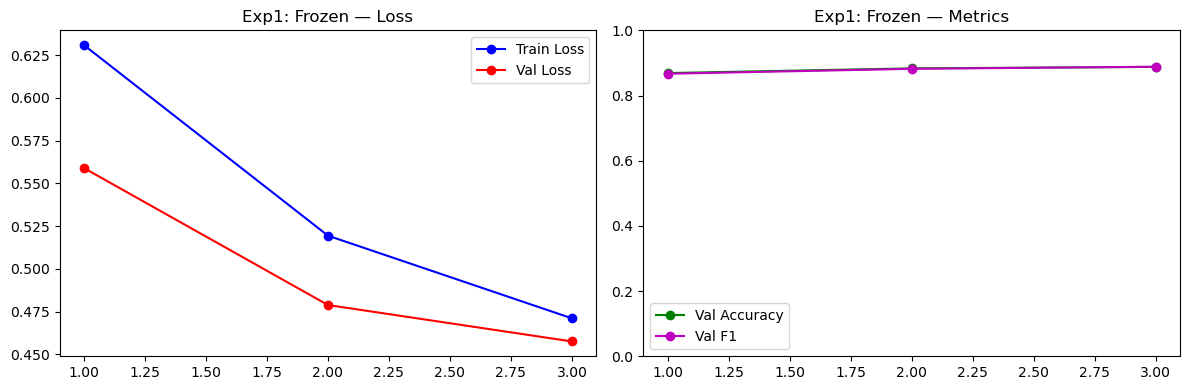

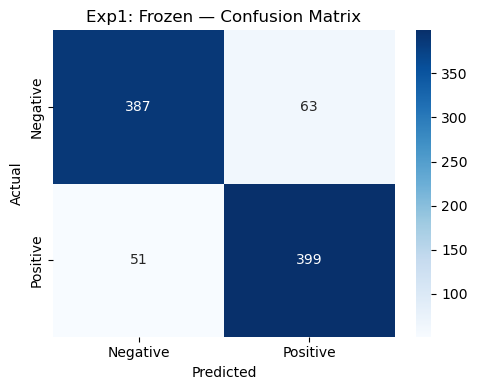

              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87       450
    Positive       0.86      0.89      0.88       450

    accuracy                           0.87       900
   macro avg       0.87      0.87      0.87       900
weighted avg       0.87      0.87      0.87       900



In [12]:
hist1, met1, preds1, lbls1 = run_experiment(
    "Exp1: Frozen DistilBERT", freeze_mode="all", epochs=3)
plot_curves(hist1, "Exp1: Frozen", "exp1_curves.png")
plot_cm(lbls1, preds1, "Exp1: Frozen — Confusion Matrix", "exp1_cm.png")
print(classification_report(lbls1, preds1, target_names=["Negative","Positive"]))


## 11. Experiment 2 — Fine-Tune Last Transformer Block
Freeze all DistilBERT layers except the final transformer block.



  Exp2: Last Block  |  freeze=last1  |  epochs=3


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable: 7,680,002 / 66,955,010 (11.5%)


  Training:   0%|          | 0/132 [00:00<?, ?it/s]

  Epoch 1/3  Train Loss: 0.4678  Val Acc: 0.9311  Val F1: 0.9306


  Training:   0%|          | 0/132 [00:00<?, ?it/s]

  Epoch 2/3  Train Loss: 0.1849  Val Acc: 0.9344  Val F1: 0.9347


  Training:   0%|          | 0/132 [00:00<?, ?it/s]

  Epoch 3/3  Train Loss: 0.1681  Val Acc: 0.9356  Val F1: 0.9357

  ── Test Results ──
  Loss        : 0.1809
  Accuracy    : 0.9356
  Precision   : 0.9242
  Recall      : 0.9489
  F1          : 0.9364


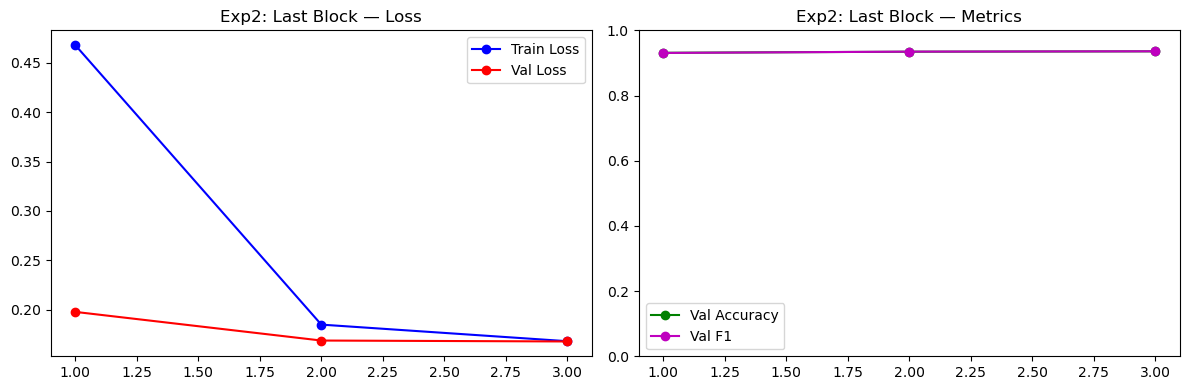

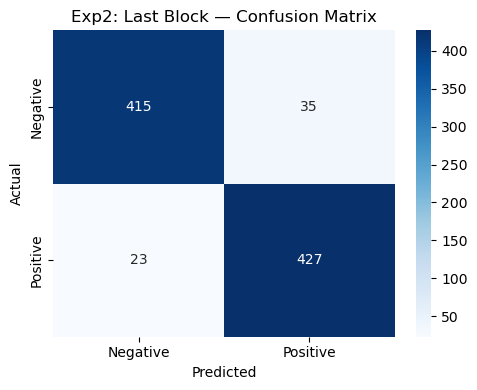

              precision    recall  f1-score   support

    Negative       0.95      0.92      0.93       450
    Positive       0.92      0.95      0.94       450

    accuracy                           0.94       900
   macro avg       0.94      0.94      0.94       900
weighted avg       0.94      0.94      0.94       900



In [13]:
hist2, met2, preds2, lbls2 = run_experiment(
    "Exp2: Last Block", freeze_mode="last1", epochs=3)
plot_curves(hist2, "Exp2: Last Block", "exp2_curves.png")
plot_cm(lbls2, preds2, "Exp2: Last Block — Confusion Matrix", "exp2_cm.png")
print(classification_report(lbls2, preds2, target_names=["Negative","Positive"]))


## 12. Experiment 3 — Full Fine-Tuning
All layers updated. Best expected performance.



  Exp3: Full Fine-Tune  |  freeze=none  |  epochs=3


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable: 66,955,010 / 66,955,010 (100.0%)


  Training:   0%|          | 0/132 [00:00<?, ?it/s]

  Epoch 1/3  Train Loss: 0.3480  Val Acc: 0.9400  Val F1: 0.9399


  Training:   0%|          | 0/132 [00:00<?, ?it/s]

  Epoch 2/3  Train Loss: 0.1283  Val Acc: 0.9356  Val F1: 0.9371


  Training:   0%|          | 0/132 [00:00<?, ?it/s]

  Epoch 3/3  Train Loss: 0.0855  Val Acc: 0.9422  Val F1: 0.9430

  ── Test Results ──
  Loss        : 0.1597
  Accuracy    : 0.9500
  Precision   : 0.9412
  Recall      : 0.9600
  F1          : 0.9505


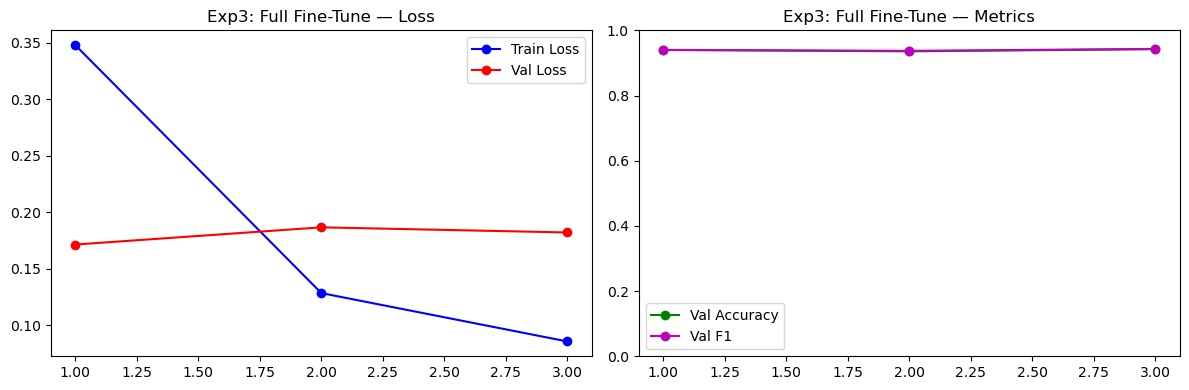

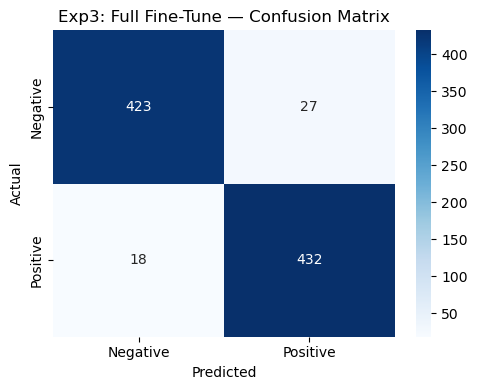

              precision    recall  f1-score   support

    Negative       0.96      0.94      0.95       450
    Positive       0.94      0.96      0.95       450

    accuracy                           0.95       900
   macro avg       0.95      0.95      0.95       900
weighted avg       0.95      0.95      0.95       900



In [14]:
hist3, met3, preds3, lbls3 = run_experiment(
    "Exp3: Full Fine-Tune", freeze_mode="none", epochs=3)
plot_curves(hist3, "Exp3: Full Fine-Tune", "exp3_curves.png")
plot_cm(lbls3, preds3, "Exp3: Full Fine-Tune — Confusion Matrix", "exp3_cm.png")
print(classification_report(lbls3, preds3, target_names=["Negative","Positive"]))


## 13. Experiment Comparison

In [15]:
results = {
    "Exp1: Frozen"     : met1,
    "Exp2: Last Block" : met2,
    "Exp3: Full FT"    : met3,
}

df_res = pd.DataFrame(results).T[["accuracy","precision","recall","f1","loss"]].round(4)
df_res.index.name = "Experiment"
print("\n" + "="*60)
print("  TEST SET METRICS COMPARISON")
print("="*60)
print(df_res.to_string())
print("="*60)
df_res



  TEST SET METRICS COMPARISON
                  accuracy  precision  recall      f1    loss
Experiment                                                   
Exp1: Frozen        0.8733     0.8636  0.8867  0.8750  0.4497
Exp2: Last Block    0.9356     0.9242  0.9489  0.9364  0.1809
Exp3: Full FT       0.9500     0.9412  0.9600  0.9505  0.1597


,accuracy,precision,recall,f1,loss
Experiment,,,,,
Exp1: Frozen,0.8733,0.8636,0.8867,0.8750,0.4497
Exp2: Last Block,0.9356,0.9242,0.9489,0.9364,0.1809
Exp3: Full FT,0.9500,0.9412,0.9600,0.9505,0.1597


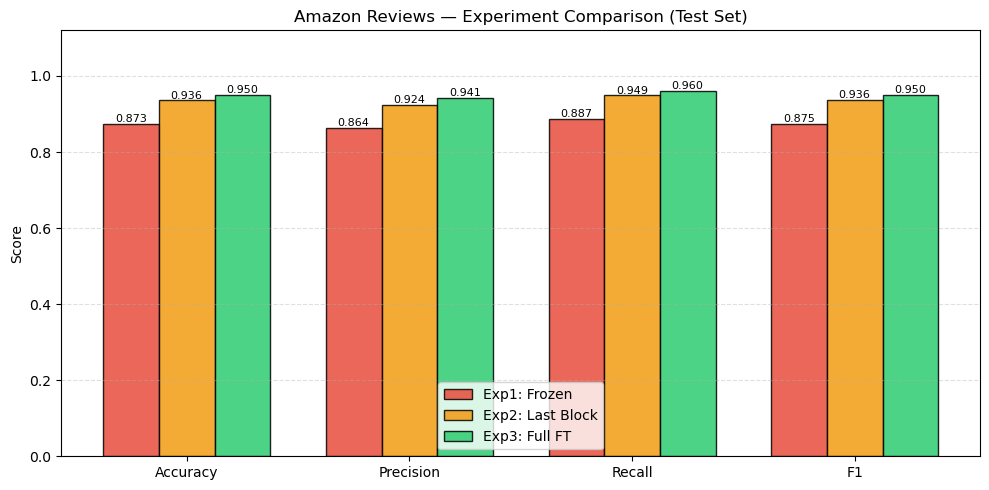

In [16]:
metrics_to_plot = ["accuracy","precision","recall","f1"]
x = np.arange(len(metrics_to_plot)); w = 0.25
colors = ["#e74c3c","#f39c12","#2ecc71"]
exps   = list(results.keys())

fig, ax = plt.subplots(figsize=(10, 5))
for i, (exp, color) in enumerate(zip(exps, colors)):
    vals = [results[exp][m] for m in metrics_to_plot]
    bars = ax.bar(x + i*w, vals, w, label=exp, color=color,
                  alpha=0.85, edgecolor="black")
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f"{b.get_height():.3f}", ha="center", fontsize=8)

ax.set_xticks(x + w); ax.set_xticklabels([m.capitalize() for m in metrics_to_plot])
ax.set_ylim(0, 1.12); ax.set_ylabel("Score")
ax.set_title("Amazon Reviews — Experiment Comparison (Test Set)")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
